In [1]:
import torch
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
words = open("./40000words.txt", "r").read().splitlines()
words[:10]

['you', 'i', 'the', 'to', 'a', 'it', 'and', 'that', 'of', 'is']

In [3]:
unique_chars = sorted(set("".join(words)))
ctoi = {c:i+1 for i,c in enumerate(unique_chars)}
ctoi["."] = 0
itoc = {i:c for c,i in ctoi.items()}
unique_chars_len = len(itoc)
print(unique_chars_len)
print(unique_chars)
print(ctoi)
print(itoc)

59
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'µ', 'à', 'á', 'â', 'ã', 'ä', 'ç', 'è', 'é', 'ê', 'ë', 'ì', 'í', 'î', 'ï', 'ñ', 'ò', 'ó', 'ô', 'ö', 'ø', 'ú', 'û', 'ü', 'ş', 'η', 'ν', 'ο', 'τ', 'υ', 'ﬁ', 'ﬂ']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, 'µ': 27, 'à': 28, 'á': 29, 'â': 30, 'ã': 31, 'ä': 32, 'ç': 33, 'è': 34, 'é': 35, 'ê': 36, 'ë': 37, 'ì': 38, 'í': 39, 'î': 40, 'ï': 41, 'ñ': 42, 'ò': 43, 'ó': 44, 'ô': 45, 'ö': 46, 'ø': 47, 'ú': 48, 'û': 49, 'ü': 50, 'ş': 51, 'η': 52, 'ν': 53, 'ο': 54, 'τ': 55, 'υ': 56, 'ﬁ': 57, 'ﬂ': 58, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22:

In [4]:
# dataset
block_size = 3
X, Y = [], []

for w in words:
    
    context = [0]*3
    
    for ch in w+".":
        
        ix = ctoi[ch]
        X.append(context)
        Y.append(ix)
        
        # print(f"{" ".join([itoc[i] for i in context])}->{itoc[ix]}")
        
        context = context[1:]+[ix]
    # print()

In [5]:
print(X[:10])
print(Y[:10])

[[0, 0, 0], [0, 0, 25], [0, 25, 15], [25, 15, 21], [0, 0, 0], [0, 0, 9], [0, 0, 0], [0, 0, 20], [0, 20, 8], [20, 8, 5]]
[25, 15, 21, 0, 9, 0, 20, 8, 5, 0]


In [6]:
Xt,Yt = torch.tensor(X), torch.tensor(Y)
print(Xt, Xt.shape, Xt.dim())
print(Yt, Yt.shape, Yt.dim())

tensor([[ 0,  0,  0],
        [ 0,  0, 25],
        [ 0, 25, 15],
        ...,
        [ 5, 18, 19],
        [18, 19,  1],
        [19,  1, 23]]) torch.Size([316864, 3]) 2
tensor([25, 15, 21,  ...,  1, 23,  0]) torch.Size([316864]) 1


In [7]:
embedding_dim = 2 
EMBEDDING_TABLE = torch.randn((unique_chars_len, embedding_dim))
EMBEDDING_TABLE[:5]

tensor([[ 1.2895, -1.5696],
        [ 0.1990, -0.3756],
        [-0.9141,  0.2616],
        [ 1.1189,  0.4933],
        [-0.2504, -0.5475]])

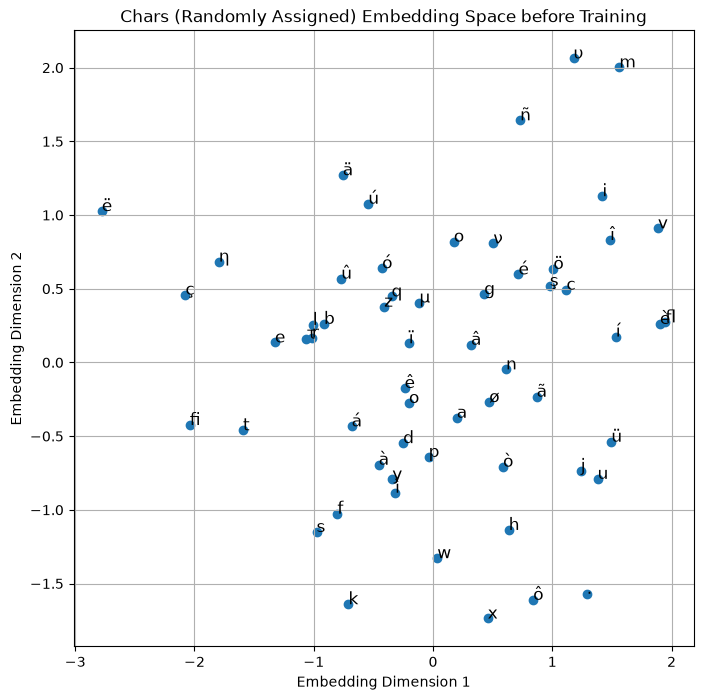

In [8]:
from word_generator.chart import plot2d_embedded_characters
plot2d_embedded_characters(
    EMBEDDING_TABLE=EMBEDDING_TABLE, 
    itos=itoc, 
    title="Chars (Randomly Assigned) Embedding Space before Training"
)

In [9]:
RANDOM_SEEED = 39244592309252
g = torch.Generator().manual_seed(RANDOM_SEEED)

In [10]:
# Shuffling
perm = torch.randperm(Xt.shape[0], generator=g)
Xt_shuffle, Yt_Shuffle = Xt[perm], Yt[perm]

In [11]:
# Splitting Dataset 
n1 = int(0.85*Xt_shuffle.shape[0])

Xt_train, Yt_train = Xt_shuffle[:n1], Yt_Shuffle[:n1]
Xt_test, Yt_test = Xt_shuffle[n1:], Yt_Shuffle[n1:]

print(f"{Xt_train[:10]=},\n {Xt_train.shape=},\n {Xt_train.dim()=}")
print()
print(f"{Yt_train[:10]=},\n {Yt_train.shape=},\n {Yt_train.dim()=}")
print("\n---------------------------------\n")
print(f"{Xt_test[:10]=},\n {Xt_test.shape=},\n {Xt_test.dim()=}")
print()
print(f"{Yt_test[:10]=},\n {Yt_test.shape=},\n {Yt_test.dim()=}")


Xt_train[:10]=tensor([[ 0,  0,  0],
        [ 0, 20,  8],
        [ 0, 19, 20],
        [ 0,  0,  0],
        [ 9, 22,  5],
        [13,  1, 20],
        [ 9, 11,  5],
        [ 0,  0, 17],
        [13,  1, 19],
        [ 0,  5, 22]]),
 Xt_train.shape=torch.Size([269334, 3]),
 Xt_train.dim()=2

Yt_train[:10]=tensor([18,  5, 21, 12,  0,  5, 18, 21, 20,  1]),
 Yt_train.shape=torch.Size([269334]),
 Yt_train.dim()=1

---------------------------------

Xt_test[:10]=tensor([[ 1, 18, 20],
        [ 0,  0,  0],
        [ 7,  5, 18],
        [20,  3,  8],
        [ 5, 18, 15],
        [22, 15,  9],
        [18, 19,  5],
        [ 0, 19, 11],
        [21,  5,  4],
        [ 6, 15, 18]]),
 Xt_test.shape=torch.Size([47530, 3]),
 Xt_test.dim()=2

Yt_test[:10]=tensor([ 8,  2, 19,  0, 21,  4, 14,  9,  5,  7]),
 Yt_test.shape=torch.Size([47530]),
 Yt_test.dim()=1


In [21]:
# MLP
total_neuron_h1 = 160
# h1
W1 = torch.randn((embedding_dim * block_size, total_neuron_h1), generator=g)
b1 = torch.randn(W1.shape[1], generator=g)

# h2
total_logits = unique_chars_len
W2 = (
    torch.randn((W1.shape[1], total_logits), generator=g) * 0.01
)  # normalize W2 to make all logits equal (it will surge down the loss from high to low at initialization)
b2 = torch.randn(W2.shape[1], generator=g) * 0

In [33]:
# parameters 
params = [EMBEDDING_TABLE, W1, b1, W2, b2]

for p in params:
    p.requires_grad = True 

sum(p.nelement() for p in params)

10737

In [32]:
# collect losses 
losses = []

In [ ]:
# Training

learning_rate = 0.1
iteration = 10000
batch_size = 32

for i in range(iteration):

    # ---- batching -> flatten (view) -> forward pass -> loss ----
    batch_ix = torch.randint(0, Xt_train.shape[0], (batch_size,))  # [32]
    xt_train_batch_emb = EMBEDDING_TABLE[Xt_train[batch_ix]]  # [32, 3, 2]
    yt_train_batch = Yt_train[batch_ix]

    xt_train_batch_emb_flat = xt_train_batch_emb.view(-1, W1.shape[0])
    hpreact = xt_train_batch_emb_flat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2

    loss = torch.nn.functional.cross_entropy(logits, yt_train_batch)

    # ---- backpropagation ----
    for p in params:
        p.grad = None
    loss.backward()

    # ---- optimization -> update ----
    with torch.no_grad():
        for p in params:
            p -= learning_rate * p.grad

    # --- collect losses ---
    losses.append(loss.item())
    if iteration >= 1000 and (i + 1) % 1000 == 0:
        print(f"iteration: {i+1}: {loss}")
    # print(loss)
    # break

iteration: 1000: 2.78796124458313
iteration: 2000: 2.459758758544922
iteration: 3000: 2.0364577770233154
iteration: 4000: 2.537529706954956
iteration: 5000: 2.761073350906372
iteration: 6000: 2.5333213806152344
iteration: 7000: 2.6404826641082764
iteration: 8000: 2.390862464904785
iteration: 9000: 2.4609339237213135
iteration: 10000: 2.4786148071289062


(array([53., 13.,  2.,  4.,  0.,  0.,  2.,  2.,  1.,  1.,  2.,  1.,  1.,
         0.,  3.,  1.,  2.,  0.,  0.,  1.,  1.,  0.,  0.,  1.,  1.,  1.,
         3.,  1.,  0.,  0.,  0.,  2.,  0.,  0.,  1.,  0.,  0.,  1.,  0.,
         0.,  0.,  1.,  0.,  0.,  2.,  3.,  3.,  2.,  3., 45.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

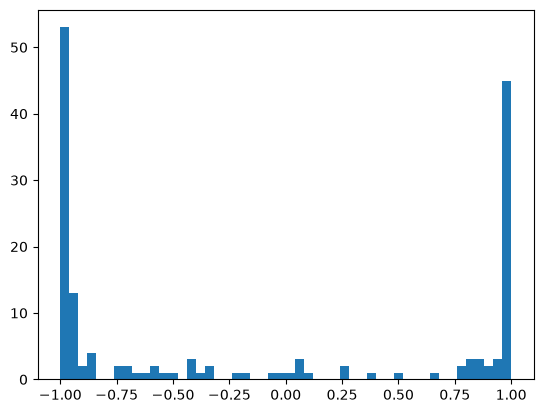

In [31]:
plt.hist(h.view(-1).tolist(), 50)

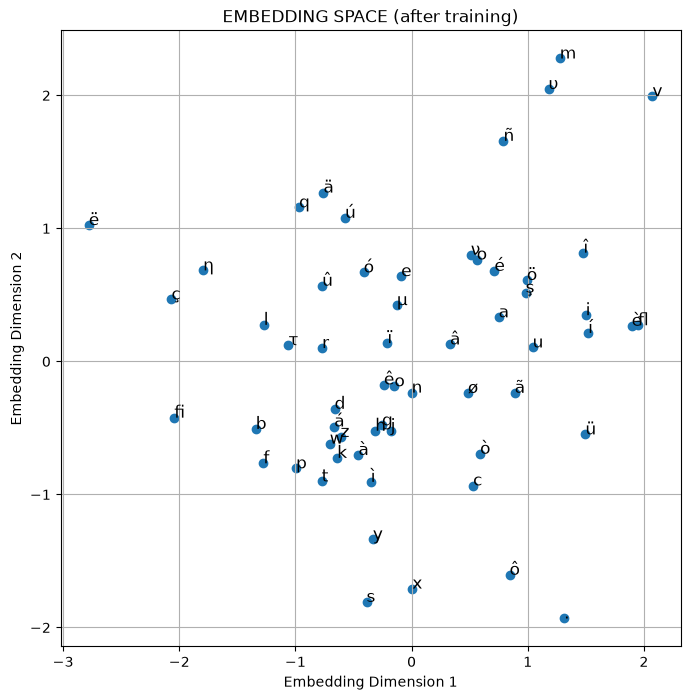

In [27]:
plot2d_embedded_characters(
    EMBEDDING_TABLE=EMBEDDING_TABLE, itos=itoc, title="EMBEDDING SPACE (after training)"
)

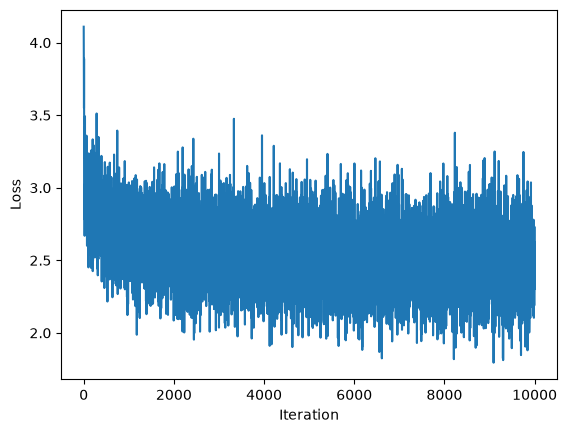

In [28]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [29]:
# Unkwon dataset test 
Xt_test_emb = EMBEDDING_TABLE[Xt_test]
Xt_test_flat = Xt_test_emb.view(-1, W1.shape[0])
test_h = torch.tanh(Xt_test_flat @ W1 + b1)
test_logits = test_h @ W2 + b2
test_loss = torch.nn.functional.cross_entropy(test_logits, Yt_test)
print(f"{test_loss=}")

test_loss=tensor(2.4723, grad_fn=<NllLossBackward0>)


In [30]:
# Sampling new words 

sample_counts = 10
samples = []

for i in range(sample_counts):

    context = [0] * block_size
    out = []
    
    while True:
        emb = EMBEDDING_TABLE[torch.tensor(context)]
        h = torch.tanh(emb.view(-1, W1.shape[0]) @ W1 + b1)
        logits = h @ W2 + b2 
        probs = torch.softmax(logits, dim=1)
        
        # next characters 
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        
        # update context 
        context = context[1:] + [ix]
        
        if ix == 0:
            break
        
        ch = itoc[ix]
        out.append(ch)
    
    samples.append("".join(out))

samples

['chang',
 'dan',
 'ince',
 'imoim',
 'markarty',
 'mat',
 'gowparatu',
 'clangy',
 'atpremn',
 've']